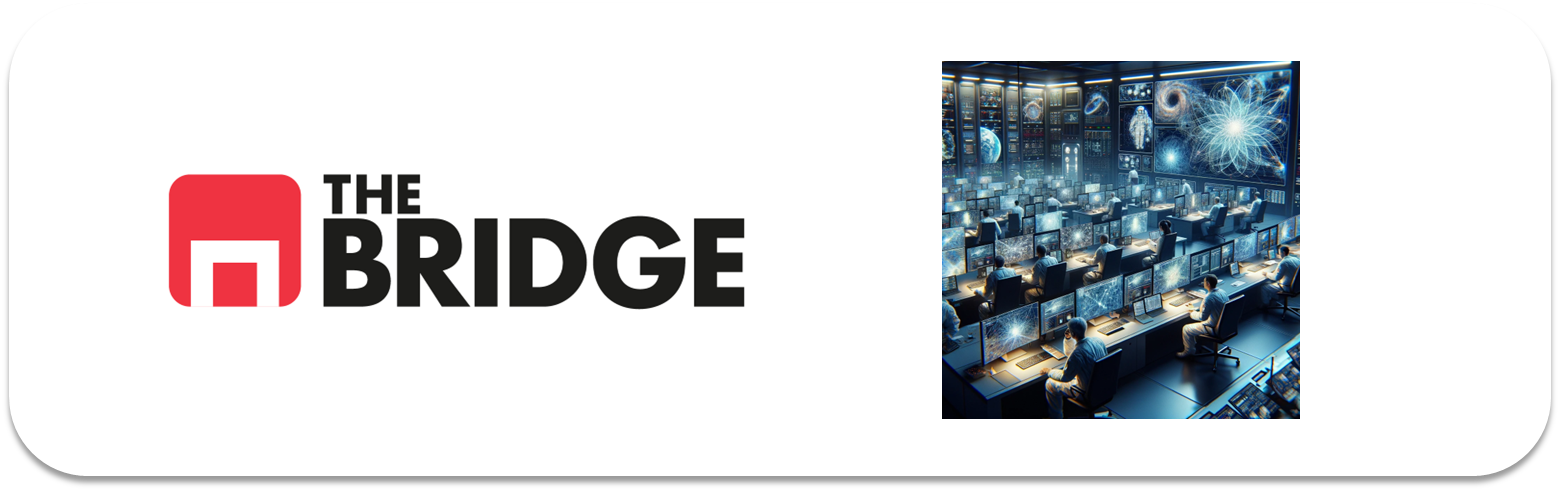

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import warnings
warnings.filterwarnings('ignore')

import keras
from keras.models import Sequential
from keras.layers import (Conv2D, MaxPool2D, Dropout, Flatten, Dense, Input,
                          RandomFlip, RandomRotation, RandomZoom)
from keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



Train shape : (4000, 32, 32, 3)  | etiquetas: (4000,)
Test  shape : (1000, 32, 32, 3)  | etiquetas: (1000,)
Dist. train → gatos: 2000, perros: 2000
Dist. test  → gatos: 500, perros: 500


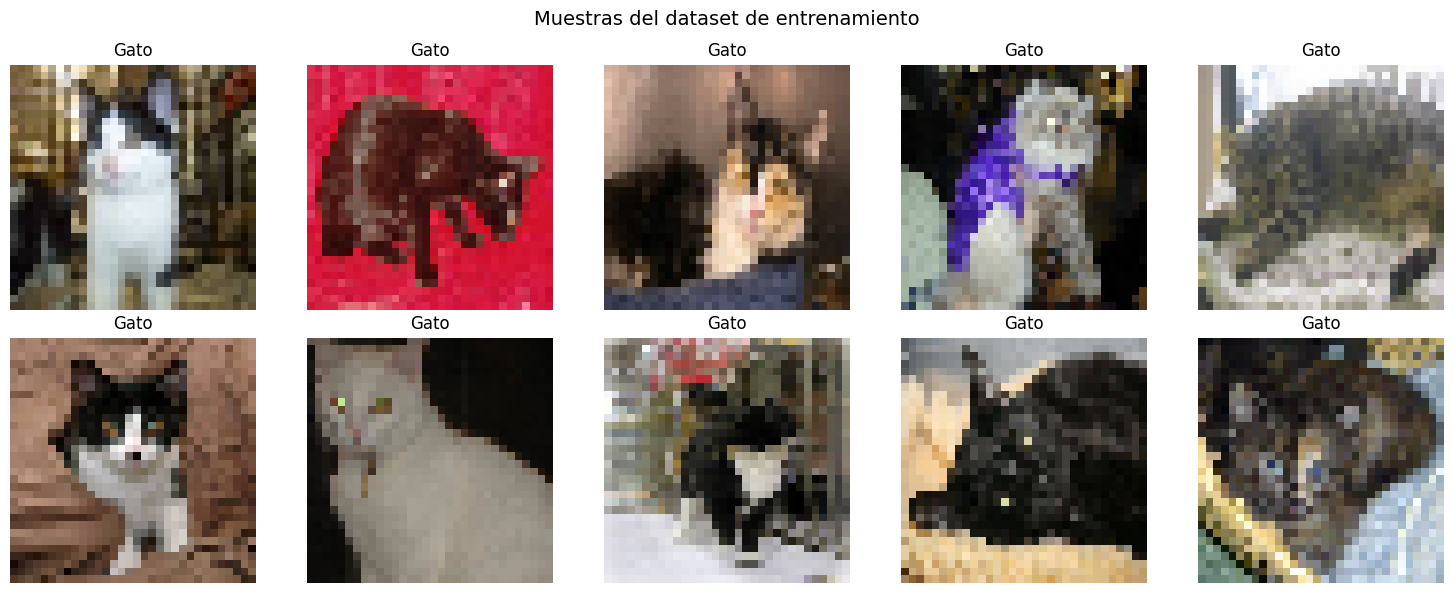

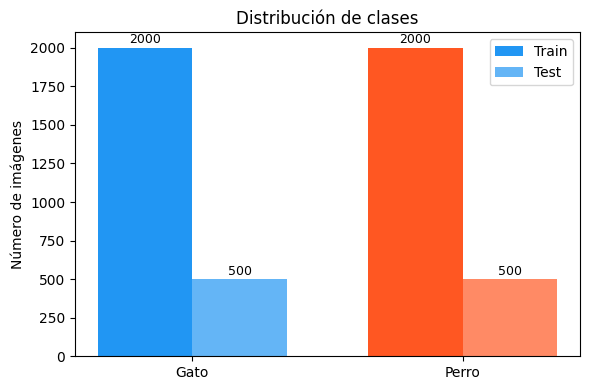

Resolución de imagen: 32x32 px, 3 canales
Rango de valores: min=0, max=255

Tras normalizar — X_train: min=0.00, max=1.00


Model: "CNN_CatsVsDogs"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,068,481 (4.08 MB)

 Trainable params: 1,068,481 (4.08 MB)

...

49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.7612 - loss: 0.5026

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.7597 - loss: 0.5033

50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 156ms/step - accuracy: 0.7597 - loss: 0.5033 - val_accuracy: 0.5325 - val_loss: 0.7908


Epoch 8: early stopping


Restoring model weights from the end of the best epoch: 3.


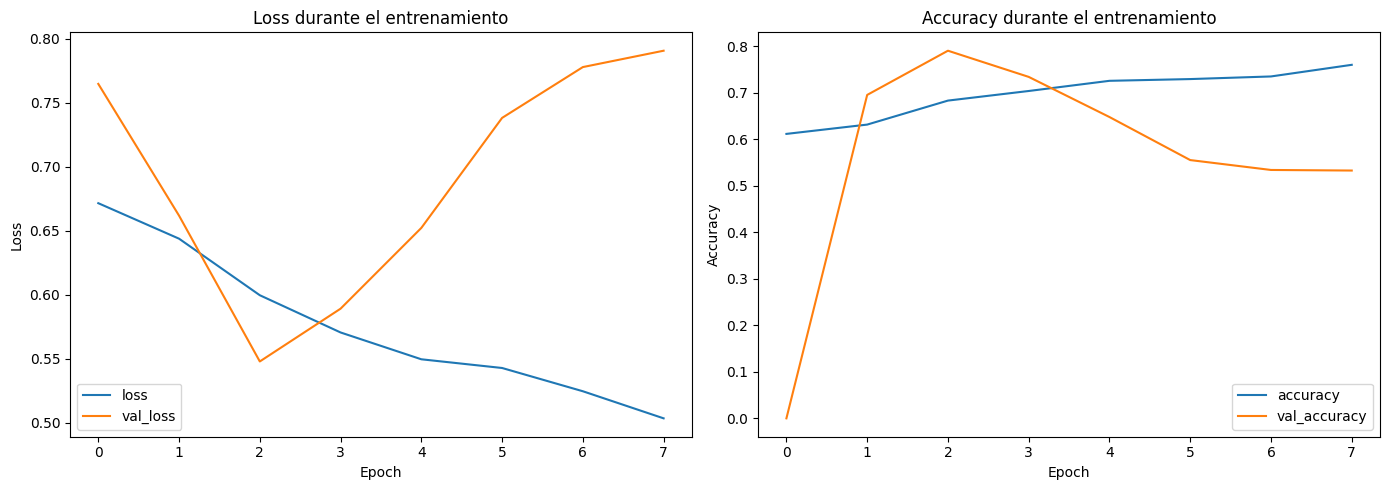


Test Loss    : 0.6048
Test Accuracy: 0.6760
 1/32 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

 3/32 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

 5/32 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

 7/32 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

10/32 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

...

23/32 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

26/32 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step



--- Classification Report ---
              precision    recall  f1-score   support

        Gato       0.73      0.56      0.63       500
       Perro       0.64      0.79      0.71       500

    accuracy                           0.68      1000
   macro avg       0.69      0.68      0.67      1000
weighted avg       0.69      0.68      0.67      1000



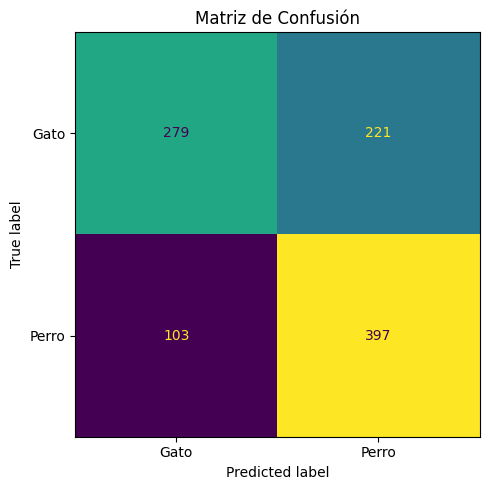

Total mal clasificadas           : 324
Gatos predichos como perros      : 221  → top 10%: 22 seleccionadas
Perros predichos como gatos      : 103 → top 10%: 10 seleccionadas


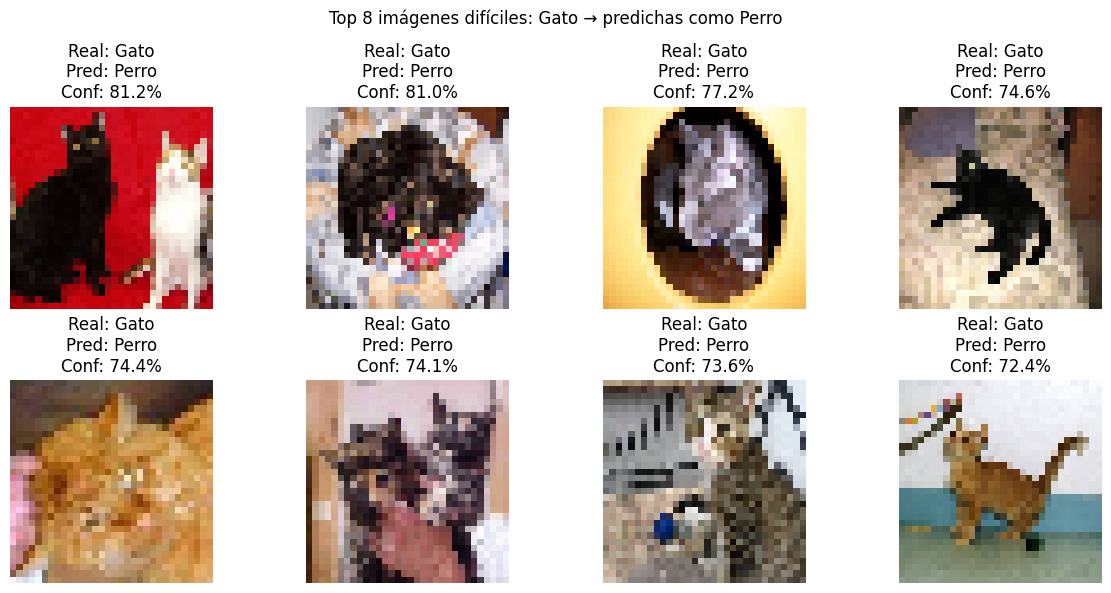

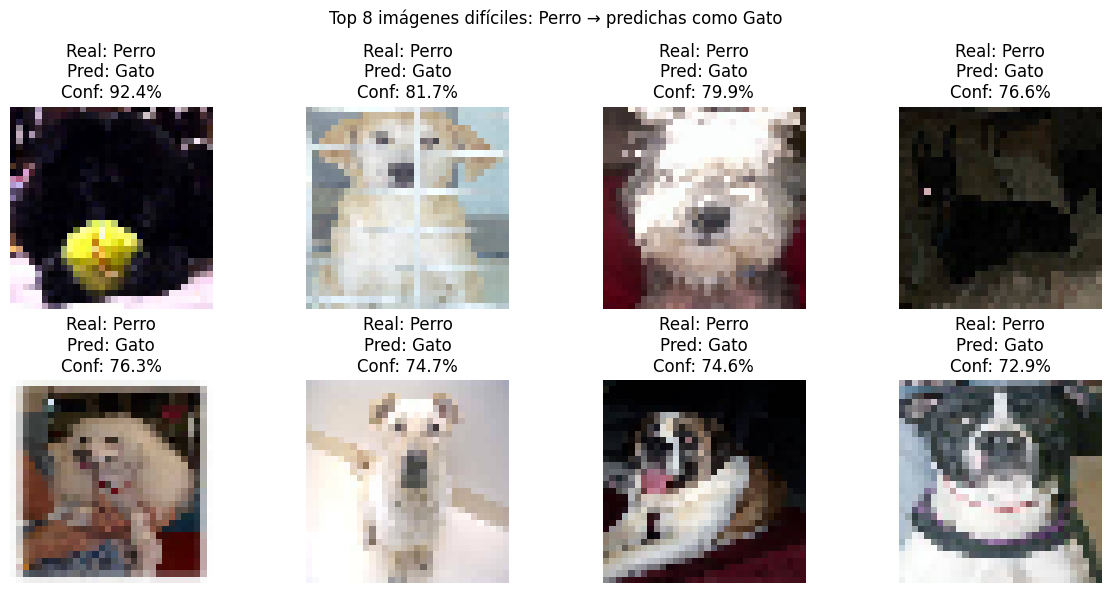

Model: "CNN_CatsVsDogs_Augmented"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,068,481 (4.08 MB)

 Trainable params: 1,068,481 (4.08 MB)

 Non-trainable params: 0 (0.00 B)

...

49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.7305 - loss: 0.5382

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.7312 - loss: 0.5378

50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 389ms/step - accuracy: 0.7312 - loss: 0.5378 - val_accuracy: 0.7837 - val_loss: 0.4778


Epoch 18: early stopping


Restoring model weights from the end of the best epoch: 13.


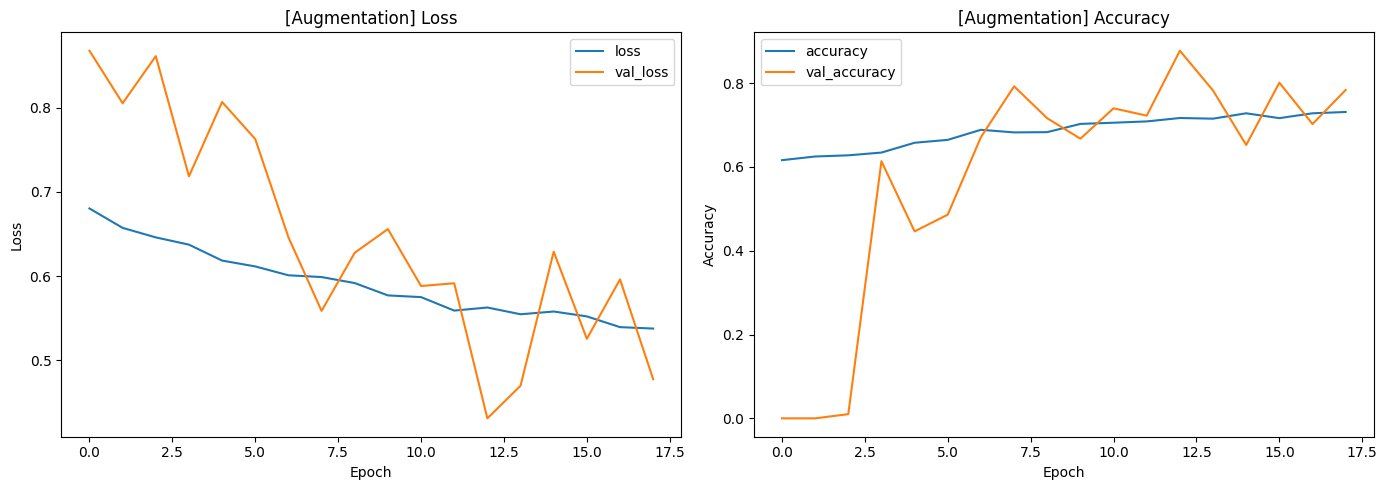


[Augmentation] Test Loss    : 0.5849
[Augmentation] Test Accuracy: 0.6710
 1/32 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

 4/32 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

 7/32 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

10/32 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

13/32 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

...

24/32 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

28/32 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step



--- Classification Report (con Augmentation) ---
              precision    recall  f1-score   support

        Gato       0.78      0.47      0.59       500
       Perro       0.62      0.87      0.73       500

    accuracy                           0.67      1000
   macro avg       0.70      0.67      0.66      1000
weighted avg       0.70      0.67      0.66      1000



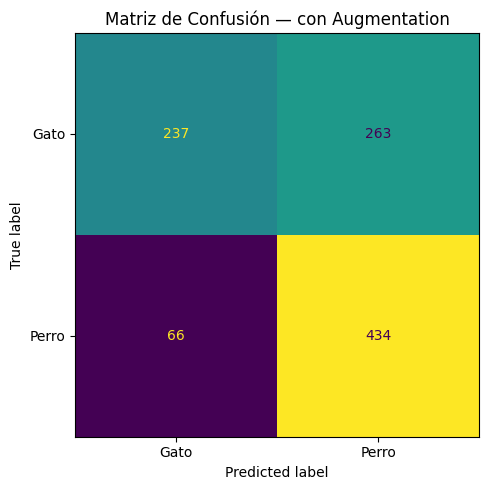


[Augmentation] Total mal clasificadas     : 329
[Augmentation] Gatos → perros: 263 → top 10%: 26
[Augmentation] Perros → gatos: 66 → top 10%: 6


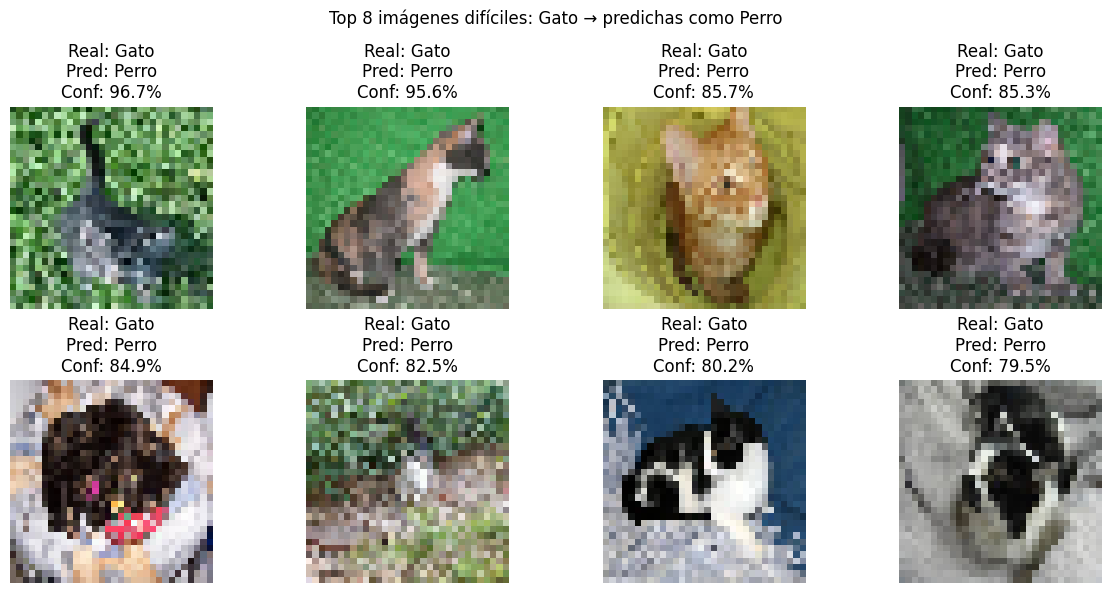

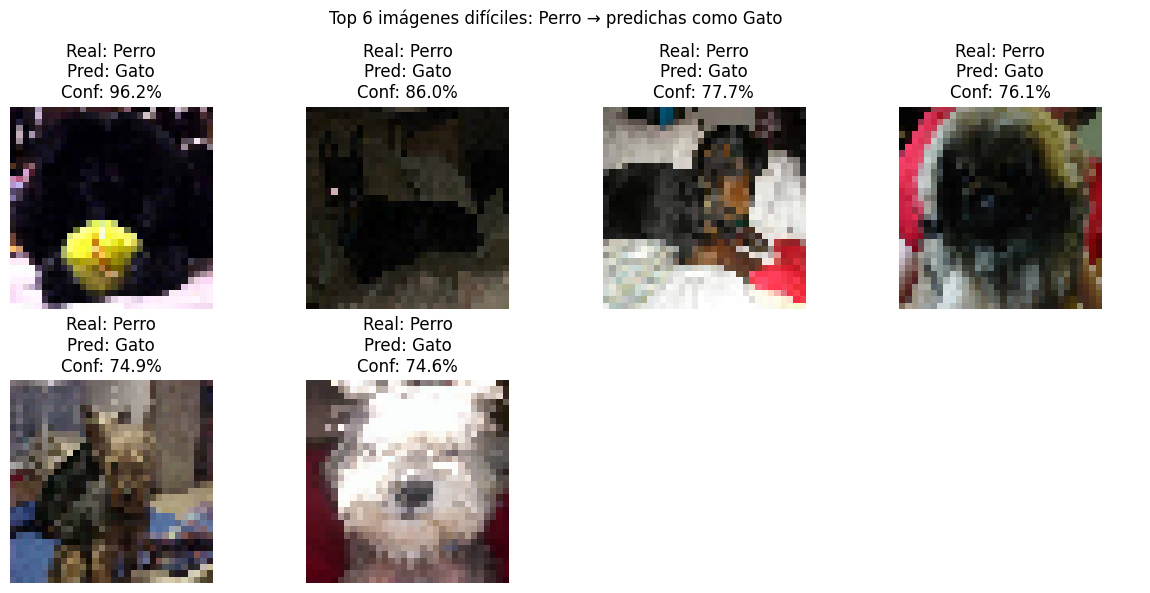

In [2]:
# ============================================================
# 1. CARGA DEL DATASET
# ============================================================

DATA_PATH = "data/"
TRAIN_DIRS = [f"github_train_{i}" for i in range(4)]
TEST_DIR   = "github_test"
IMG_SIZE   = (32, 32)

def load_images_from_dir(directory):
    X, y = [], []
    for filename in sorted(os.listdir(directory)):
        if not filename.lower().endswith('.jpg'):
            continue
        label = 0 if filename.startswith('cat') else 1  # cat=0, dog=1
        img_path = os.path.join(directory, filename)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)
        X.append(img)
        y.append(label)
    return X, y

# Train: concatenar los 4 directorios
X_train_list, y_train_list = [], []
for td in TRAIN_DIRS:
    Xp, yp = load_images_from_dir(os.path.join(DATA_PATH, td))
    X_train_list.extend(Xp)
    y_train_list.extend(yp)

# Test
X_test_list, y_test_list = load_images_from_dir(os.path.join(DATA_PATH, TEST_DIR))

X_train_raw = np.array(X_train_list)
y_train      = np.array(y_train_list)
X_test_raw  = np.array(X_test_list)
y_test       = np.array(y_test_list)

print(f"Train shape : {X_train_raw.shape}  | etiquetas: {y_train.shape}")
print(f"Test  shape : {X_test_raw.shape}  | etiquetas: {y_test.shape}")
print(f"Dist. train → gatos: {(y_train==0).sum()}, perros: {(y_train==1).sum()}")
print(f"Dist. test  → gatos: {(y_test==0).sum()}, perros: {(y_test==1).sum()}")

# ============================================================
# 2. VISUALIZACIÓN Y MINIEDA
# ============================================================

CLASS_NAMES = {0: 'Gato', 1: 'Perro'}

# Muestra de imágenes
n_show = 10
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_raw[i])
    ax.set_title(CLASS_NAMES[y_train[i]])
    ax.axis('off')
fig.suptitle("Muestras del dataset de entrenamiento", fontsize=14)
plt.tight_layout()
plt.show()

# Distribución de clases
fig, ax = plt.subplots(figsize=(6, 4))
counts_train = [(y_train==0).sum(), (y_train==1).sum()]
counts_test  = [(y_test==0).sum(),  (y_test==1).sum()]
x = np.arange(2)
w = 0.35
bars1 = ax.bar(x - w/2, counts_train, w, label='Train', color=['#2196F3','#FF5722'])
bars2 = ax.bar(x + w/2, counts_test,  w, label='Test',  color=['#64B5F6','#FF8A65'])
ax.set_xticks(x); ax.set_xticklabels(['Gato', 'Perro'])
ax.set_title("Distribución de clases")
ax.set_ylabel("Número de imágenes")
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print(f"Resolución de imagen: {X_train_raw.shape[1]}x{X_train_raw.shape[2]} px, {X_train_raw.shape[3]} canales")
print(f"Rango de valores: min={X_train_raw.min()}, max={X_train_raw.max()}")

# ============================================================
# 3. PREPROCESADO
# ============================================================

X_train = X_train_raw.astype('float32') / 255.0
X_test  = X_test_raw.astype('float32')  / 255.0

print(f"\nTras normalizar — X_train: min={X_train.min():.2f}, max={X_train.max():.2f}")

# ============================================================
# 4. MODELO CNN (2 bloques Conv-Pool)
# ============================================================

model = Sequential([
    Input(shape=(32, 32, 3)),

    # Bloque 1: Conv(32 filtros, 3x3) → MaxPool(2x2) → Dropout
    Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu'),
    MaxPool2D(pool_size=(2, 2), strides=(2, 2)),
    Dropout(0.25),

    # Bloque 2: Conv(64 filtros, 3x3) → MaxPool(2x2) → Dropout
    Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'),
    MaxPool2D(pool_size=(2, 2), strides=(2, 2)),
    Dropout(0.25),

    # Cabeza densa
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Clasificación binaria: cat=0, dog=1
], name="CNN_CatsVsDogs")

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# ============================================================
# 5. ENTRENAMIENTO CON EARLYSTOPPING
# ============================================================

early_stop = EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True, verbose=1)

history = model.fit(
    X_train, y_train,
    batch_size=64,
    epochs=30,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Historial
history_df = pd.DataFrame(history.history)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
history_df[['loss', 'val_loss']].plot(ax=axes[0])
axes[0].set_title("Loss durante el entrenamiento"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
history_df[['accuracy', 'val_accuracy']].plot(ax=axes[1])
axes[1].set_title("Accuracy durante el entrenamiento"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
plt.tight_layout(); plt.show()

# ============================================================
# 6. EVALUACIÓN
# ============================================================

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

predictions_prob = model.predict(X_test).flatten()
y_pred = (predictions_prob >= 0.5).astype(int)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Gato', 'Perro']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
    display_labels=['Gato', 'Perro'], ax=ax, colorbar=False)
ax.set_title("Matriz de Confusión")
plt.tight_layout(); plt.show()

# ============================================================
# 7. SELECCIÓN DE IMÁGENES DIFÍCILES (10% por clase)
# ============================================================

def plot_hard_cases(indices, images_raw, probs, label_true, label_pred, n_show=8):
    n = min(n_show, len(indices))
    if n == 0:
        print(f"  (ningún caso: {label_true} → {label_pred})")
        return
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3), squeeze=False)
    axes = axes.flatten()
    for i, idx in enumerate(indices[:n]):
        axes[i].imshow(images_raw[idx])
        axes[i].set_title(f"Real: {label_true}\nPred: {label_pred}\nConf: {probs[i]:.1%}")
        axes[i].axis('off')
    for j in range(n, len(axes)):
        axes[j].axis('off')
    plt.suptitle(f"Top {n} imágenes difíciles: {label_true} → predichas como {label_pred}", fontsize=12)
    plt.tight_layout(); plt.show()

misclassified = y_pred != y_test

# Gatos mal clasificados como perros → mayor prob de ser perro (predictions_prob alto)
cat_as_dog_idx  = np.where(misclassified & (y_test == 0))[0]
cat_as_dog_conf = predictions_prob[cat_as_dog_idx]

# Perros mal clasificados como gatos → mayor prob de ser gato (1 - predictions_prob alto)
dog_as_cat_idx  = np.where(misclassified & (y_test == 1))[0]
dog_as_cat_conf = 1 - predictions_prob[dog_as_cat_idx]

n_cat_sel = max(1, int(len(cat_as_dog_idx) * 0.10))
n_dog_sel = max(1, int(len(dog_as_cat_idx) * 0.10))

top_cat = cat_as_dog_idx[np.argsort(cat_as_dog_conf)[::-1][:n_cat_sel]]
top_dog = dog_as_cat_idx[np.argsort(dog_as_cat_conf)[::-1][:n_dog_sel]]

print(f"Total mal clasificadas           : {misclassified.sum()}")
print(f"Gatos predichos como perros      : {len(cat_as_dog_idx)}  → top 10%: {n_cat_sel} seleccionadas")
print(f"Perros predichos como gatos      : {len(dog_as_cat_idx)} → top 10%: {n_dog_sel} seleccionadas")

plot_hard_cases(top_cat, X_test_raw, cat_as_dog_conf[np.argsort(cat_as_dog_conf)[::-1]], 'Gato', 'Perro')
plot_hard_cases(top_dog, X_test_raw, dog_as_cat_conf[np.argsort(dog_as_cat_conf)[::-1]], 'Perro', 'Gato')

# ============================================================
# EXTRA: IMAGE AUGMENTATION CON KERAS
# ============================================================

# Modelo con capas de augmentación integradas (solo activas en train)
model_aug = Sequential([
    Input(shape=(32, 32, 3)),

    # Augmentación (solo durante entrenamiento)
    RandomFlip("horizontal"),
    RandomRotation(0.10),
    RandomZoom(0.10),

    # Bloque 1
    Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu'),
    MaxPool2D(pool_size=(2, 2), strides=(2, 2)),
    Dropout(0.25),

    # Bloque 2
    Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'),
    MaxPool2D(pool_size=(2, 2), strides=(2, 2)),
    Dropout(0.25),

    # Cabeza densa
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
], name="CNN_CatsVsDogs_Augmented")

model_aug.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_aug.summary()

early_stop_aug = EarlyStopping(monitor='val_loss', patience=5,
                                restore_best_weights=True, verbose=1)

history_aug = model_aug.fit(
    X_train, y_train,
    batch_size=64,
    epochs=30,
    validation_split=0.2,
    callbacks=[early_stop_aug],
    verbose=1
)

# Historial augmented
history_aug_df = pd.DataFrame(history_aug.history)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
history_aug_df[['loss', 'val_loss']].plot(ax=axes[0])
axes[0].set_title("[Augmentation] Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
history_aug_df[['accuracy', 'val_accuracy']].plot(ax=axes[1])
axes[1].set_title("[Augmentation] Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
plt.tight_layout(); plt.show()

# Evaluación modelo aumentado
aug_loss, aug_acc = model_aug.evaluate(X_test, y_test, verbose=0)
print(f"\n[Augmentation] Test Loss    : {aug_loss:.4f}")
print(f"[Augmentation] Test Accuracy: {aug_acc:.4f}")

pred_aug_prob = model_aug.predict(X_test).flatten()
y_pred_aug    = (pred_aug_prob >= 0.5).astype(int)

print("\n--- Classification Report (con Augmentation) ---")
print(classification_report(y_test, y_pred_aug, target_names=['Gato', 'Perro']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_aug,
    display_labels=['Gato', 'Perro'], ax=ax, colorbar=False)
ax.set_title("Matriz de Confusión — con Augmentation")
plt.tight_layout(); plt.show()

# Selección 10% imágenes difíciles con modelo augmentado
misclassified_aug = y_pred_aug != y_test
cat_as_dog_aug  = np.where(misclassified_aug & (y_test == 0))[0]
dog_as_cat_aug  = np.where(misclassified_aug & (y_test == 1))[0]

cat_conf_aug = pred_aug_prob[cat_as_dog_aug]
dog_conf_aug = 1 - pred_aug_prob[dog_as_cat_aug]

n_cat_aug = max(1, int(len(cat_as_dog_aug) * 0.10))
n_dog_aug = max(1, int(len(dog_as_cat_aug) * 0.10))

top_cat_aug = cat_as_dog_aug[np.argsort(cat_conf_aug)[::-1][:n_cat_aug]]
top_dog_aug = dog_as_cat_aug[np.argsort(dog_conf_aug)[::-1][:n_dog_aug]]

print(f"\n[Augmentation] Total mal clasificadas     : {misclassified_aug.sum()}")
print(f"[Augmentation] Gatos → perros: {len(cat_as_dog_aug)} → top 10%: {n_cat_aug}")
print(f"[Augmentation] Perros → gatos: {len(dog_as_cat_aug)} → top 10%: {n_dog_aug}")

plot_hard_cases(top_cat_aug, X_test_raw, cat_conf_aug[np.argsort(cat_conf_aug)[::-1]], 'Gato', 'Perro')
plot_hard_cases(top_dog_aug, X_test_raw, dog_conf_aug[np.argsort(dog_conf_aug)[::-1]], 'Perro', 'Gato')